<a href="https://colab.research.google.com/github/Sachintripathi123/DELTA-DEMO/blob/main/Anomoly_Detection_of_credit_card_using_Isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

In [2]:
data = {
    'Transcation_id':[],
    'Amount':[],
    'Transaction_hours':[],
    "Merchant_Category":  [],
    "Location": [],
    'Card_age_year':[],
     "Transactions_Last_24Hrs":[]
}

In [3]:
for i in range(1,10000):
    data['Transcation_id'].append(i)
    data['Amount'].append(random.randint(1000,50000))
    data['Transaction_hours'].append(random.randint(1,24))
    data['Merchant_Category'].append(random.choice(["Shopping", "Food", "Travel", "Fuel", "Entertainment"]))
    data['Location'].append(random.choice(['Mumbai','Lucknow','Delhi','Noida','Gurgao']))
    data['Card_age_year'].append(random.randint(1,15))
    data['Transactions_Last_24Hrs'].append(random.randint(1,30))

In [4]:
df = pd.DataFrame(data)
fraud_index = np.random.choice(df.index, size=100, replace=False)
df['Fraud'] = 0
df.loc[fraud_index,'Fraud']=1
df.loc[fraud_index, "Amount"] = np.random.randint(70000, 200000, len(fraud_index))
df.loc[fraud_index, "Transactions_Last_24Hrs"] = np.random.randint(40, 100, len(fraud_index))

In [5]:
df

,Transcation_id,Amount,Transaction_hours,Merchant_Category,Location,Card_age_year,Transactions_Last_24Hrs,Fraud
0,1,44300,7,Travel,Mumbai,8,12,0
1,2,39415,8,Food,Noida,4,21,0
2,3,44681,19,Fuel,Delhi,14,7,0
3,4,44549,10,Fuel,Gurgao,15,6,0
4,5,19205,1,Travel,Mumbai,8,13,0
...,...,...,...,...,...,...,...,...
9994,9995,28008,8,Travel,Noida,3,30,0
9995,9996,21127,16,Fuel,Delhi,7,30,0
9996,9997,46327,2,Shopping,Delhi,13,6,0
9997,9998,17896,6,Travel,Gurgao,2,30,0


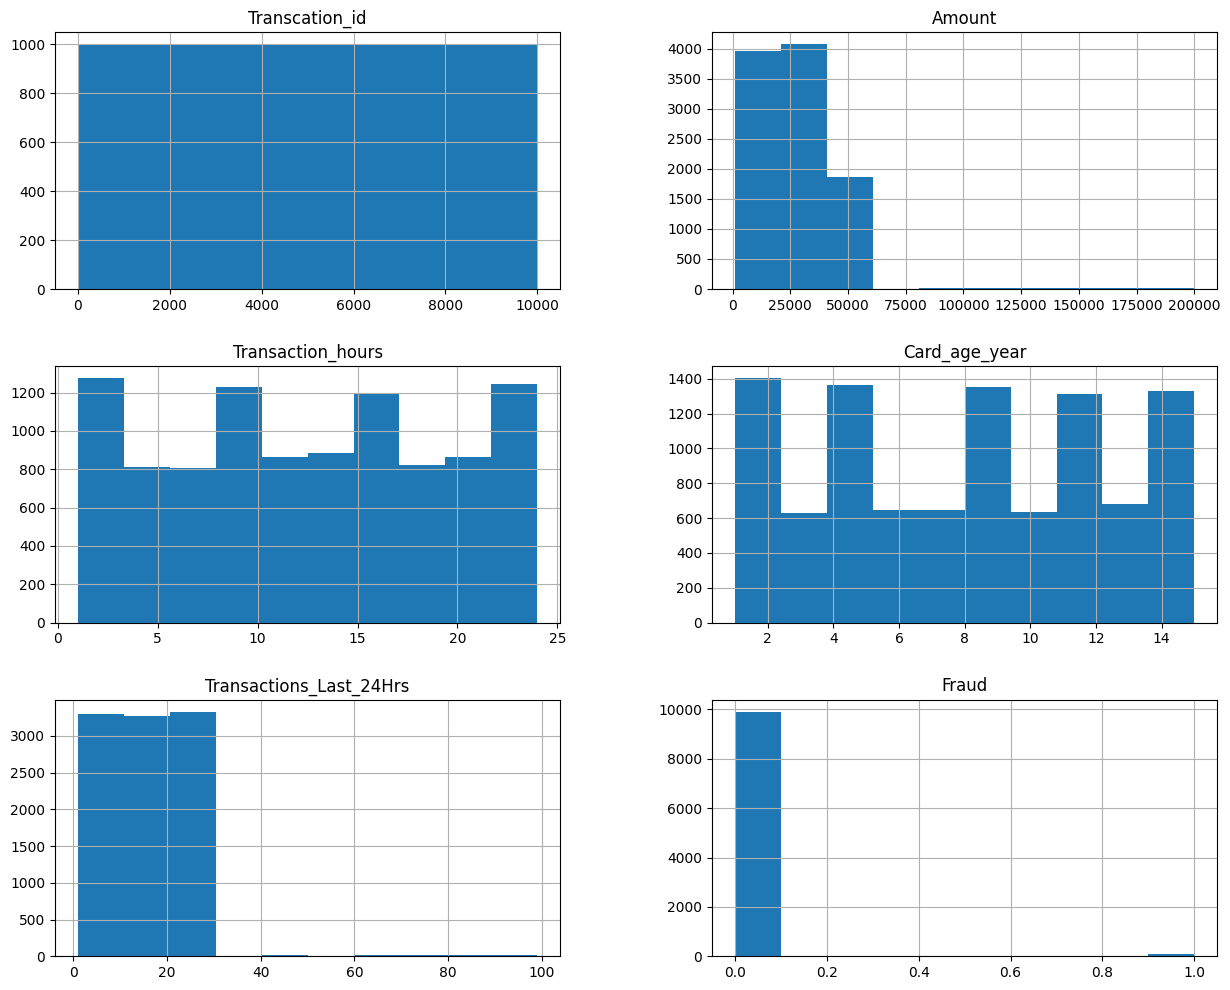

In [6]:
df.hist(figsize=(15,12))
plt.show()

In [7]:
new_df = pd.get_dummies(df,columns=['Location','Merchant_Category'],dtype=int)

In [12]:
new_df

,Transcation_id,Amount,Transaction_hours,Card_age_year,Transactions_Last_24Hrs,Fraud,Location_Delhi,Location_Gurgao,Location_Lucknow,Location_Mumbai,Location_Noida,Merchant_Category_Entertainment,Merchant_Category_Food,Merchant_Category_Fuel,Merchant_Category_Shopping,Merchant_Category_Travel
0,1,44300,7,8,12,0,0,0,0,1,0,0,0,0,0,1
1,2,39415,8,4,21,0,0,0,0,0,1,0,1,0,0,0
2,3,44681,19,14,7,0,1,0,0,0,0,0,0,1,0,0
3,4,44549,10,15,6,0,0,1,0,0,0,0,0,1,0,0
4,5,19205,1,8,13,0,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,9995,28008,8,3,30,0,0,0,0,0,1,0,0,0,0,1
9995,9996,21127,16,7,30,0,1,0,0,0,0,0,0,1,0,0
9996,9997,46327,2,13,6,0,1,0,0,0,0,0,0,0,1,0
9997,9998,17896,6,2,30,0,0,1,0,0,0,0,0,0,0,1


In [11]:
scaller = StandardScaler()
scalled = scaller.fit_transform(new_df)
scalled

array([[-1.73187759,  0.92873788, -0.79500148, ..., -0.50455889,
        -0.50658601,  2.00237835],
       [-1.73153115,  0.66853779, -0.65042027, ..., -0.50455889,
        -0.50658601, -0.49940612],
       [-1.7311847 ,  0.94903189,  0.93997311, ...,  1.9819292 ,
        -0.50658601, -0.49940612],
       ...,
       [ 1.7311847 ,  1.03670627, -1.51790756, ..., -0.50455889,
         1.97399846, -0.49940612],
       [ 1.73153115, -0.47767422, -0.9395827 , ..., -0.50455889,
        -0.50658601,  2.00237835],
       [ 1.73187759, -0.9339432 ,  0.07248581, ..., -0.50455889,
        -0.50658601, -0.49940612]])

In [13]:
pca = PCA(n_components=2)
x = pca.fit_transform(scalled)
x

array([[ 0.33604091, -0.97281995],
       [ 0.43673043,  0.53421676],
       [-0.01648561, -0.35507927],
       ...,
       [ 0.09987615, -1.69223306],
       [ 0.37525813,  0.12152013],
       [-0.63117539,  1.06603322]])

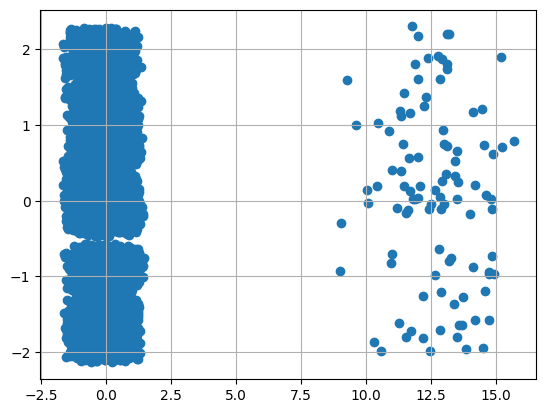

In [14]:
plt.scatter(x[:,0],x[:,1])
plt.grid(True)
plt.show()

In [15]:
anomoly = IsolationForest(contamination=0.02)

x_anomoly = anomoly.fit_predict(scalled)
x_anomoly

array([ 1,  1,  1, ..., -1, -1,  1])

In [16]:
pd.Series(anomoly).value_counts()

,count
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=933921096)",1
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=1916818931)",1
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=1904680044)",1
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=2047539165)",1
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=1147907259)",1
...,...
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=530100887)",1
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=1502610862)",1
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=242741694)",1
"ExtraTreeRegressor(max_depth=8, max_features=1, random_state=1601380782)",1


In [17]:
df["Anomoly"] = x_anomoly
df["Anomoly"].value_counts()

,count
Anomoly,
1,9799
-1,200


In [18]:
df.columns

Index(['Transcation_id', 'Amount', 'Transaction_hours', 'Merchant_Category',
       'Location', 'Card_age_year', 'Transactions_Last_24Hrs', 'Fraud',
       'Anomoly'],
      dtype='object')

In [19]:
new_deatils = [[1,72836,22,6,22,0	,0,0,1,0,0,0,0,0,0,1]]
new_scalled = scaller.transform(new_deatils)
new_anomoly = anomoly.predict(new_scalled)
new_anomoly

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1])

In [20]:


T_id = int(input("Enter Your Transaction ID: "))
A = int(input("Enter Your Transaction Amount: "))
T_Hours = int(input("Enter Your Transaction Hours: "))
c_a_y = int(input("Enter Your Card Age Year: "))
T_hour_L24 = int(input("Enter Your Transaction of Last 24: "))
print("Press 1 For Your Location Else Press 0")
L_D = int(input("Is Your Location is Delhi "))
L_M = int(input("Is Your Location is Mumbai "))
L_L = int(input("Is Your Location is Lucknow "))
L_G = int(input("Is Your Location is Gurgao "))
L_N = int(input("Is Your Location is Noida "))
print("Press 1 For Your Correct Merchant Category Else Press 0")
M_S = int(input("Is Your Merchant Category is Shopping "))
M_F = int(input("Is Your Merchant Category is Food "))
M_T = int(input("Is Your Merchant Category is Travel "))
M_E  = int(input("Is Your Merchant Category is Entertainment "))
M_Fu = int(input("Is Your Merchant Category is Fuel "))
Fraud = 0

new_data = [[
    T_id,
    A,
    T_Hours,
    c_a_y,
    T_hour_L24,
    L_D, L_M, L_L, L_G, L_N,
    M_S, M_F, M_T, M_E, M_Fu,
    Fraud
]]
new_scalled1 = scaller.transform(new_data)
new = anomoly.predict(new_scalled1)
new

Enter Your Transaction ID: 10001
Enter Your Transaction Amount: 50000
Enter Your Transaction Hours: 12
Enter Your Card Age Year: 15
Enter Your Transaction of Last 24: 24
Press 1 For Your Location Else Press 0
Is Your Location is Delhi 0
Is Your Location is Mumbai 1
Is Your Location is Lucknow 0
Is Your Location is Gurgao 0
Is Your Location is Noida 0
Press 1 For Your Correct Merchant Category Else Press 0
Is Your Merchant Category is Shopping 0
Is Your Merchant Category is Food 0
Is Your Merchant Category is Travel 1
Is Your Merchant Category is Entertainment 0
Is Your Merchant Category is Fuel 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([-1])

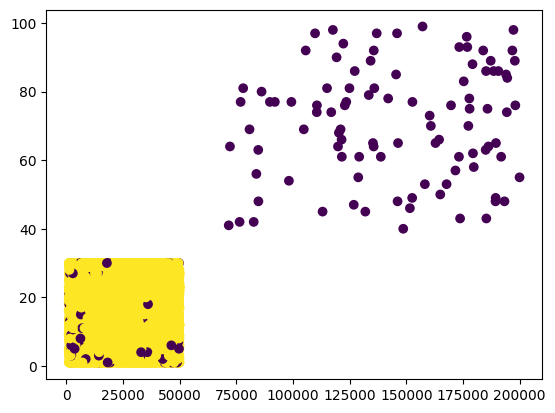

In [22]:
plt.scatter(df['Amount'],df['Transactions_Last_24Hrs'],c=df['Anomoly'])
plt.show()